# Plot surface velocity from SWOT data

### <span style="color:blue"> A critical question among the physical oceanographic research community is, "Can we use SWOT to estimate geostrophic surface currents?" The fact that SWOT has data across a swath means that we have information on the gradients from a single pass of the satellite. How convinient! We could, in theory, just do the calculation using the gradients of height over the swath. However, recall that the geostrophic balance requires sufficiently long time scales and large spatial scales. These criteria may no longer be met at the scales which SWOT resolves. 

### Tranchant et al. 2025 "As a step toward estimating accurate upper‐ocean velocities from SWOT data, we propose a novel approach by directly fitting spatial derivatives from SWOT SSH observations. This method reduces errors caused by noise and unbalanced SSH by adjusting the length scale used to derive geostrophic velocities and higher‐order balances." This method has been adopted by the SWOT level 3 production team and is now distributed in the product. You can access the toolbox associated with this paper here: https://github.com/treden/swotdiag. The critical questions addressed by the paper are:

<b>• Can we identify a length scale below which SWOT SSH data may no longer be valid to infer surface velocities in the standing meander south of Tasmania region?</b>
    <br> &emsp; • For the denoised SSH, the optimal fitting kernel size is 9 points (18 km). Applied respectively to the original and denoised SSH fields, both kernel sizes correspond to an effective filtering length scale of approximately 25 km. SWOT provides accurate velocity estimates in excellent agreement with low‐pass filtered (>1 day) in‐situ velocity observations, even for higher velocities. In contrast, DUACS smooths out smaller‐scale features, resulting in significant discrepancies with ground‐truth velocities, especially in the higher velocity range.

<b>• How significant are higher‐order balanced motions at the scales resolved by SWOT?</b>
    <br> &emsp; • The geostrophic approximation becomes inaccurate at the scales resolved by SWOT. We show that using geostrophic approximation leads to a persistent bias in the comparison between SWOT‐derived velocities and drifter observations, with differences reaching up to +10–20% in cyclonic eddies. This bias is effectively corrected by applying cyclogeostrophy to SWOT SSH. In contrast, due to resolution limitations, DUACS geostrophic velocities underestimate drifter velocities, and the discrepancy is further amplified when applying cyclogeostrophy in cyclonic conditions.

<b>• Does the balanced surface velocity field derived from SWOT explain the small‐scale dispersion properties observed in drifter pairs deployed during the FOCUS voyage?</b>
    <br> &emsp; • Virtual particles released in SWOT velocity fields effectively reproduce dispersion properties of drifter pairs over the 10–200 km range, accurately representing particle separation rates, velocity correlations, and associated regime behavior. Within this range, small‐scale balanced motions predominantly govern local dispersion. Using only SWOT‐derived virtual particles, we then characterized the spatial variability of dispersion properties in the meander. The results indicate that dispersion rates are primarily influenced by interactions with the meander and topographic features, but exhibit distinct patterns between mesoscale and smaller‐scale dispersion dynamics.


Notebook co-produced by A. Rodriguez, A. Nambiathody, and C. Camargo for the 2026 SSiSLS.

In [1]:
# Geostrophic Velocity Computation and comparisons
# Comparison with Geostrophic velocity provided by the SWOT Product v3 product by
# 1. calculating the slope by fitting a linear plane kernel to 2D SSH observations - gradients by fitting planes of 9 × 9 pixels
# 2.calculating the slope a central grid point involves differencing adjacent SSH in both the x and y directions

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import matplotlib.cm as mplcm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
sys.path.append('../')
from src.diagnosis import *
import os

In [3]:
script_dir = "../"
swot_data_path = os.path.join(script_dir, "data/SWOT_LR_L3v3/expert/")
# dont forget to change this to your local one
files = sorted(os.listdir(swot_data_path))

This script uses the absolute dynamic topography (ADT), i.e., the height relative to the geoid, to calculate the geostrophic velocities. Recall the diagram
![Alt Text](ADT_diagram.png)
We will, thus, use the variables MDT and the SSHA (labeled SLA in the diagram) to compute the ADT.

In [4]:
# === Load L3 Variables ===
ds = xr.open_dataset(swot_data_path+files[10])
ssha =ds.ssha_filtered
mdt  = ds.mdt
lon_swot = ds.longitude
lat_swot = ds.latitude

ugos_swot = ds.ugos_filtered
vgos_swot = ds.vgos_filtered

This approach enables selective filtering of short-wavelength signals that may include unbalanced motions inconsistent with the geostrophic approximation. The geostrophic velocity are computed from the slope of the linear plane kernel fitted to 2D SSH observations. A fitting length scale of 18 km (9-point) is identified as a trade-off between reducing residual unbalanced SSH while preserving fine-scale balanced motions in denoised SSH.

In [5]:
%%capture suppressed_output  
## keep above to supress user folder path

# === Calculate velocities using Tranchant method ===

params = dict(derivative = 'fit', # Derivative obtained by the fitting method instead of point difference
          n = 9, # 9*9 point kernels
          min_valid_points = 0.75, # Ratio of valid points to compute the derivative (e.g. 75% valid points are necessary to compute the derivatives, useful to avoid boundary effects)
          avoid_negative = False, # Parameter that avoid negative values in the SQRT using the GW formulation (leading to invalid values in the solutions)
          kernel = 'square', # can be circular or a square, the shape of the kernel
          );

## Diagnostics from original SSH
diag = compute_ocean_diagnostics_from_eta(ssha+mdt , lon_swot,lat_swot, **params)

In [6]:
dims = ds.ugos_filtered.dims
swot_derived = ds.assign(ugos_derived = (dims, diag['ug']), vgos_derived = (dims, diag['vg']))

In [7]:
# Defines the extent to plot
lon_min = -73
lon_max=-65
lat_min=36
lat_max= 45

In [8]:
# === Comute the geostrophic velocities from the slopes of the ADT ===

# Calculate adt 
ds['adt'] = ds['ssha_unfiltered'] + ds['mdt']
ds['adt'].attrs = {'units':'m','long_name':'Absolute dynamic topography'}
# We compute the slopes on the ADT as we computed in the previous question
adt = np.array(ds.adt)


In [9]:
# Compute the slopes
slope_alongtrack, slope_crosstrack = np.gradient(adt)
slope_alongtrack = slope_alongtrack / 2000 # OBS: Be aware of the units! Before we were happy with m/km, but now we need m/m!
slope_crosstrack = slope_crosstrack / 2000 # OBS: Be aware of the units! Before we were happy with m/km, but now we need m/m!
slope_magnitude = np.sqrt((slope_alongtrack)**2 + (slope_crosstrack)**2)


def R(theta):
    # For the definition see: https://en.wikipedia.org/wiki/Rotation_matrix
    return np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

# We have to determine the orbit angle theta
# A rough way is to know the inclination of SWOT is about 78 degrees:
theta = 180 - (90-78)
# But this is not entirely accurate.

# If we think about the cross-track and along-track slopes as a vector, we can gather all the SWOT observations into a 2xN matrix
# We use .reshape(-1) in order to reformat the 2D SWOT matrix into two columns and put them side by side
# Convert to N-E
slopes_vector = np.c_[slope_alongtrack.reshape(-1), slope_crosstrack.reshape(-1)].T
slopes_ne = R(np.deg2rad(theta)) @ slopes_vector


g = 9.82
Omega = 7.282e-5

# ---------------------------------------------------
# Coriolis parameter
# ---------------------------------------------------
f = 2 * Omega * np.sin(np.deg2rad(ds['latitude']))

# Now we compute the geostrophic currents from the equations
u = - g/f * slopes_ne[0,:].reshape(adt.shape)
v = g/f * slopes_ne[1,:].reshape(adt.shape)


/var/folders/qs/ljm8_6xj1_d76r9nbgnxgm2nyrdbs6/T/ipykernel_17167/987001160.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 0.8, 0.71])


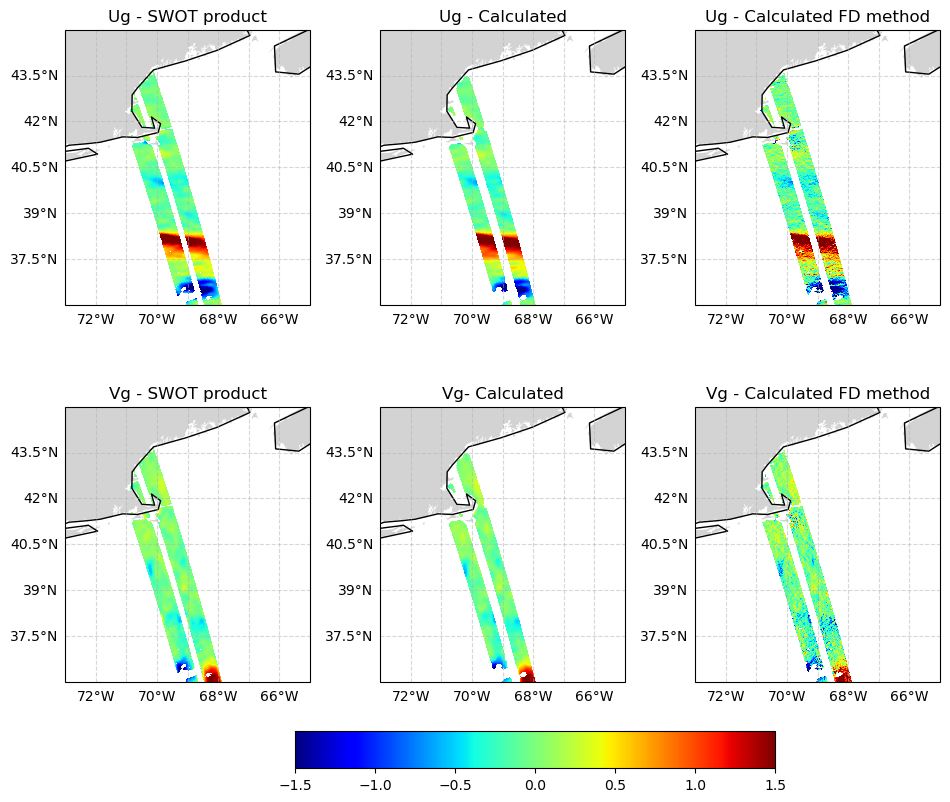

In [10]:
fig, axes = plt.subplots(2, 3,figsize=(12, 15), subplot_kw=dict(projection=ccrs.PlateCarree()),sharex=True,sharey=True)

pcm = axes[0,0].pcolormesh(lon_swot,lat_swot.latitude,ugos_swot,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[0,0].set_title("Ug - SWOT product")


pcm = axes[0,1].pcolormesh(swot_derived.longitude,swot_derived.latitude,swot_derived.ugos_derived,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[0,1].set_title("Ug - Calculated")

pcm = axes[0,2].pcolormesh(lon_swot,lat_swot,u,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[0,2].set_title("Ug - Calculated FD method")


pcm = axes[1,0].pcolormesh(lon_swot,lat_swot,vgos_swot,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[1,0].set_title("Vg - SWOT product")


pcm = axes[1,1].pcolormesh(swot_derived.longitude,swot_derived.latitude,swot_derived.vgos_derived,cmap='jet',
                           vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[1,1].set_title("Vg- Calculated")

pcm = axes[1,2].pcolormesh(lon_swot,lat_swot,v,cmap='jet',vmin=-1.5,vmax=1.5,transform=ccrs.PlateCarree())
axes[1,2].set_title("Vg - Calculated FD method")

for ax in axes.flat:
    ax.coastlines(resolution="110m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    gl = ax.gridlines(draw_labels=True,linestyle="--",alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_extent([lon_min, lon_max, lat_min, lat_max],crs=ccrs.PlateCarree())

cax = fig.add_axes([0.25, 0.12, 0.4, 0.025])

cb = fig.colorbar(pcm,cax=cax,orientation="horizontal")

plt.tight_layout(rect=[0, 0.08, 0.8, 0.71])

plt.show()